# FolpsD vs COMET EFT multipoles

This notebook compares FolpsD EFT redshift-space multipoles against COMET
`EFT_nonu` for one non-neutrino cosmology.  It focuses on the four bias
parameters and checks the FolpsD `priordoc` and `classpt` bias conventions
against COMET's `EggScoSmi` and `AssBauGre` bases.

The run uses CLASS for the linear power spectrum and disables AP, TNS, VDG,
counterterms, stochastic terms, and neutrino corrections.

If this notebook is run from the FolpsD `notebooks/` directory, it imports
FolpsD from the parent repository automatically.  Otherwise set
`FOLPSD_ROOT=/path/to/FolpsD` before launching Jupyter.


In [1]:
%matplotlib inline

import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "numpy")

candidate_roots = []
if os.environ.get("FOLPSD_ROOT"):
    candidate_roots.append(Path(os.environ["FOLPSD_ROOT"]).expanduser())
candidate_roots.extend([Path.cwd().parent, Path.cwd()])

folps_source_root = None
for candidate in candidate_roots:
    if (candidate / "folps").exists():
        sys.path.insert(0, str(candidate))
        folps_source_root = candidate
        break

import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from comet import comet
from folps import (
    MatrixCalculator,
    NonLinearPowerSpectrumCalculator,
    RSDMultipolesPowerSpectrumCalculator,
)

warnings.filterwarnings("ignore", message="Trying to unpickle estimator")
warnings.filterwarnings("ignore", category=FutureWarning)

if folps_source_root is None:
    print("Using installed FolpsD package")
else:
    print(f"Using FolpsD source tree: {folps_source_root}")


Warning! "libgrid.so" not found, bispectrum binning options will not be available.
✅ Using NumPy with CPU.
Using FolpsD source tree: /Users/waco/Codes/FolpsD


## Bias bases

From FolpsD's `set_bias_scheme("priordoc")`, the four-parameter
`priordoc` vector is

$$
\theta_{\rm FolpsD,priordoc} =
(b_1^{\rm prior}, b_2^{\rm prior}, b_{K^2}^{\rm prior}, b_{\rm td}^{\rm prior}).
$$

COMET's default `EggScoSmi` basis is

$$
\theta_{\rm COMET,EggScoSmi} = (b_1, b_2, g_2, g_{21}).
$$

The code-derived map is linear with no constant offset:

$$
\begin{aligned}
b_1 &= b_1^{\rm prior},\\
b_2 &= b_2^{\rm prior} + \frac{4}{3}b_{K^2}^{\rm prior},\\
g_2 &= b_{K^2}^{\rm prior},\\
g_{21} &= -\frac{4}{7}\left(b_{K^2}^{\rm prior}+b_{\rm td}^{\rm prior}\right).
\end{aligned}
$$

We also compare FolpsD `classpt`,

$$
\theta_{\rm FolpsD,classPT} =
(b_1^{\rm classPT}, b_2^{\rm classPT}, b_{G_2}^{\rm classPT}, b_{\Gamma_3}^{\rm classPT}),
$$

to COMET `EggScoSmi` through

$$
g_{21} = -\frac{4}{7}\left(b_{G_2}^{\rm classPT}+b_{\Gamma_3}^{\rm classPT}\right),
$$

and directly to COMET `AssBauGre`, whose input order is
$(b_1,b_2,b_{G_2},b_{\Gamma_3})$.


In [2]:
FOLPS_PRIORDOC_BIAS_NAMES = ["b1_priordoc", "b2_priordoc", "bK2_priordoc", "btd_priordoc"]
FOLPS_CLASSPT_BIAS_NAMES = ["b1_classPT", "b2_classPT", "bG2_classPT", "bGamma3_classPT"]
COMET_EGGSCO_BIAS_NAMES = ["b1", "b2", "g2", "g21"]
COMET_ASSBAUGRE_BIAS_NAMES = ["b1", "b2", "bG2", "bGam3"]

A_PRIORDOC_TO_COMET_EGG = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 4.0 / 3.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, -4.0 / 7.0, -4.0 / 7.0],
    ]
)
A_CLASSPT_TO_COMET_EGG = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, -4.0 / 7.0, -4.0 / 7.0],
    ]
)
C_ANALYTIC = np.zeros(4)

print("theta_folps_priordoc =", FOLPS_PRIORDOC_BIAS_NAMES)
print("theta_folps_classpt =", FOLPS_CLASSPT_BIAS_NAMES)
print("theta_comet_EggScoSmi =", COMET_EGGSCO_BIAS_NAMES)
print("theta_comet_AssBauGre =", COMET_ASSBAUGRE_BIAS_NAMES)
print()
print("A_priordoc_to_comet_egg =")
print(A_PRIORDOC_TO_COMET_EGG)
print("c =", C_ANALYTIC)


theta_folps_priordoc = ['b1_priordoc', 'b2_priordoc', 'bK2_priordoc', 'btd_priordoc']
theta_folps_classpt = ['b1_classPT', 'b2_classPT', 'bG2_classPT', 'bGamma3_classPT']
theta_comet_EggScoSmi = ['b1', 'b2', 'g2', 'g21']
theta_comet_AssBauGre = ['b1', 'b2', 'bG2', 'bGam3']

A_priordoc_to_comet_egg =
[[ 1.          0.          0.          0.        ]
 [ 0.          1.          1.33333333  0.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.         -0.57142857 -0.57142857]]
c = [0. 0. 0. 0.]


## Cosmology and helper functions


In [3]:
COSMO = {
    "h": 0.6736,
    "wb": 0.02237,
    "wc": 0.12000,
    "ns": 0.965,
    "As_comet": 2.1,  # COMET convention; CLASS A_s is this times 1e-9.
    "z": 0.8,
}

BIAS_TESTS_PRIORDOC = [
    ("linear-only", np.array([1.70, 0.00, 0.00, 0.00])),
    ("b2-shift", np.array([1.70, 0.55, 0.00, 0.00])),
    ("positive-tidal", np.array([1.70, -0.40, 0.15, -0.20])),
    ("negative-tidal", np.array([1.40, 0.20, -0.25, 0.35])),
    ("mixed-high-bias", np.array([2.05, -0.75, 0.30, 0.10])),
]

CACHE_DIR = Path(os.environ.get("FOLPSD_CACHE_DIR", ".folpsd_cache"))
CACHE_DIR.mkdir(exist_ok=True)


In [4]:
def class_linear_pk(cosmo_params):
    # Return k[h/Mpc], P_lin[(Mpc/h)^3], and f(z) from CLASS.
    h = cosmo_params["h"]
    z = cosmo_params["z"]
    cls = Class()
    cls.set(
        {
            "output": "mPk",
            "omega_b": cosmo_params["wb"],
            "omega_cdm": cosmo_params["wc"],
            "h": h,
            "A_s": cosmo_params["As_comet"] * 1.0e-9,
            "n_s": cosmo_params["ns"],
            "P_k_max_1/Mpc": 2.5,
            "z_max_pk": 3.0,
            "N_ur": 3.046,
            "N_ncdm": 0,
        }
    )
    cls.compute()
    try:
        k = np.logspace(-4, np.log10(2.0), 600)
        pk = np.array([cls.pk_lin(ki * h, z) * h**3 for ki in k])
        fz = float(cls.scale_independent_growth_factor_f(z))
    finally:
        cls.struct_cleanup()
        cls.empty()
    return k, pk, fz


def build_folps_context(k, pk, f0):
    h = COSMO["h"]
    omega_m = (COSMO["wb"] + COSMO["wc"]) / h**2

    matrix = MatrixCalculator(A_full=True, use_TNS_model=False, save_dir=str(CACHE_DIR))
    mmatrices = matrix.get_mmatrices()

    nonlinear = NonLinearPowerSpectrumCalculator(
        mmatrices=mmatrices,
        kernels="fk",
        z=COSMO["z"],
        h=h,
        Omega_m=omega_m,
        fnu=0.0,
        f0=f0,
    )
    table, table_now = nonlinear.calculate_loop_table(
        k=k,
        pklin=pk,
        cosmo=None,
        z=COSMO["z"],
        h=h,
        Omega_m=omega_m,
        fnu=0.0,
        f0=f0,
    )
    multipoles = RSDMultipolesPowerSpectrumCalculator(model="EFT")
    return multipoles, table, table_now


def folps_stack(theta_folps, ctx, k_eval, ells=(0, 2, 4), bias_scheme="priordoc"):
    multipoles, table, table_now = ctx
    pars = list(np.asarray(theta_folps, dtype=float)) + [0.0] * 8
    pell = multipoles.get_rsd_pkell(
        kobs=k_eval,
        qpar=1.0,
        qper=1.0,
        pars=pars,
        table=table,
        table_now=table_now,
        bias_scheme=bias_scheme,
        nmu=8,
        ells=ells,
        IR_resummation=True,
        damping=None,
    )
    return np.asarray(pell).reshape(-1)


def build_comet_context(bias_basis="EggScoSmi"):
    emu = comet(model="EFT_nonu", use_Mpc=False, bias_basis=bias_basis)
    params = {
        "wb": COSMO["wb"],
        "wc": COSMO["wc"],
        "ns": COSMO["ns"],
        "h": COSMO["h"],
        "Ok": 0.0,
        "z": COSMO["z"],
        "As": COSMO["As_comet"],
        "sigma_z": 0.0,
        "f_out": 0.0,
    }
    return emu, params


def comet_stack(theta_comet, ctx, k_eval, ells=(0, 2, 4), bias_names=COMET_EGGSCO_BIAS_NAMES):
    emu, base_params = ctx
    params = dict(base_params)
    params.update(dict(zip(bias_names, np.asarray(theta_comet, dtype=float))))
    pell = emu.Pell(k_eval, params, list(ells), de_model="lambda", q_tr_lo=[1.0, 1.0])
    return np.vstack([pell[f"ell{ell}"] for ell in ells]).reshape(-1)


In [5]:
def centered_jacobian(func, theta, step=1.0e-3):
    theta = np.asarray(theta, dtype=float)
    cols = []
    for i in range(theta.size):
        delta = np.zeros_like(theta)
        delta[i] = step
        cols.append((func(theta + delta) - func(theta - delta)) / (2.0 * step))
    return np.column_stack(cols)


def relative_norm(model, reference):
    return float(np.linalg.norm(model - reference) / np.linalg.norm(reference))


def max_fractional_residual(model, reference):
    denom = np.maximum(np.abs(reference), 1.0)
    return float(np.max(np.abs(model - reference) / denom))


def comparison_metrics(model, reference):
    return {
        "rel_norm": relative_norm(model, reference),
        "max_frac": max_fractional_residual(model, reference),
        "max_abs": float(np.max(np.abs(model - reference))),
    }


def multipole_slices(k_eval, ells=(0, 2, 4)):
    return {ell: slice(i * k_eval.size, (i + 1) * k_eval.size) for i, ell in enumerate(ells)}


def priordoc_to_classpt(theta_priordoc):
    b1, b2, bK2, btd = np.asarray(theta_priordoc, dtype=float)
    return np.array([b1, b2 + 4.0 / 3.0 * bK2, bK2, btd])


def markdown_table(headers, rows):
    header = "| " + " | ".join(headers) + " |"
    sep = "| " + " | ".join(["---"] * len(headers)) + " |"
    body = ["| " + " | ".join(row) + " |" for row in rows]
    return "\n".join([header, sep] + body)


## Build the theory objects


In [6]:
k_class, pk_class, f0_class = class_linear_pk(COSMO)
folps_ctx = build_folps_context(k_class, pk_class, f0_class)
comet_egg_ctx = build_comet_context("EggScoSmi")
comet_assbaugre_ctx = build_comet_context("AssBauGre")
k_eval = np.linspace(0.02, 0.18, 25)

print(f"CLASS f(z={COSMO['z']}) = {f0_class:.8f}")
print("k comparison range:", (k_eval.min(), k_eval.max()), "h/Mpc")


Loading matrices from /Users/waco/Documents/FolpsVsVelocileptors/.folpsd_cache/matrices_nfftlog128_Afull-True_use_TNS-False.npy


CLASS f(z=0.8) = 0.83969854
k comparison range: (np.float64(0.02), np.float64(0.18)) h/Mpc


## Linear-response validation

The next cell compares finite-difference response matrices around a
representative point.  The fitted matrix is not used as the answer; it is
only a numerical cross-check of the analytic, code-derived map above.


In [7]:
theta_folps0 = np.array([1.7, -0.4, 0.15, -0.2])
theta_classpt0 = priordoc_to_classpt(theta_folps0)
theta_comet0 = A_PRIORDOC_TO_COMET_EGG @ theta_folps0 + C_ANALYTIC
theta_comet_classpt0 = A_CLASSPT_TO_COMET_EGG @ theta_classpt0 + C_ANALYTIC

folps_priordoc_func = lambda th: folps_stack(th, folps_ctx, k_eval, bias_scheme="priordoc")
folps_classpt_func = lambda th: folps_stack(th, folps_ctx, k_eval, bias_scheme="classpt")
comet_egg_func = lambda th: comet_stack(th, comet_egg_ctx, k_eval, bias_names=COMET_EGGSCO_BIAS_NAMES)
comet_assbaugre_func = lambda th: comet_stack(
    th, comet_assbaugre_ctx, k_eval, bias_names=COMET_ASSBAUGRE_BIAS_NAMES
)

j_folps = centered_jacobian(folps_priordoc_func, theta_folps0)
j_comet = centered_jacobian(comet_egg_func, theta_comet0)
a_fit = np.linalg.lstsq(j_comet, j_folps, rcond=None)[0]

residual_analytic = j_comet @ A_PRIORDOC_TO_COMET_EGG - j_folps
residual_fit = j_comet @ a_fit - j_folps

j_folps_classpt = centered_jacobian(folps_classpt_func, theta_classpt0)
j_comet_classpt = centered_jacobian(comet_egg_func, theta_comet_classpt0)
a_classpt_fit = np.linalg.lstsq(j_comet_classpt, j_folps_classpt, rcond=None)[0]
residual_classpt_analytic = j_comet_classpt @ A_CLASSPT_TO_COMET_EGG - j_folps_classpt
residual_classpt_fit = j_comet_classpt @ a_classpt_fit - j_folps_classpt

print("theta_folps0 =", theta_folps0)
print("theta_comet0 =", theta_comet0)
print()
print("A_fit for priordoc -> COMET EggScoSmi:")
print(a_fit)
print()
print("A_fit - A:")
print(a_fit - A_PRIORDOC_TO_COMET_EGG)
print()
print(
    "Combined relative residual, analytic A:",
    np.linalg.norm(residual_analytic) / np.linalg.norm(j_folps),
)
print(
    "Combined relative residual, fitted A:",
    np.linalg.norm(residual_fit) / np.linalg.norm(j_folps),
)
print(
    "Combined relative residual, classpt analytic A:",
    np.linalg.norm(residual_classpt_analytic) / np.linalg.norm(j_folps_classpt),
)
print(
    "Combined relative residual, classpt fitted A:",
    np.linalg.norm(residual_classpt_fit) / np.linalg.norm(j_folps_classpt),
)


theta_folps0 = [ 1.7  -0.4   0.15 -0.2 ]
theta_comet0 = [ 1.7        -0.2         0.15        0.02857143]

A_fit for priordoc -> COMET EggScoSmi:
[[ 9.99807559e-01 -4.10232950e-06 -2.52602847e-05 -1.11281817e-05]
 [-9.93129250e-03  9.98036723e-01  1.30451571e+00 -1.14017808e-02]
 [-1.22885804e-02 -1.12417291e-03  9.83669376e-01 -6.34941799e-03]
 [-1.18770117e-02 -9.03637079e-04 -5.85610643e-01 -5.76904017e-01]]

A_fit - A:
[[-1.92441383e-04 -4.10232950e-06 -2.52602847e-05 -1.11281817e-05]
 [-9.93129250e-03 -1.96327702e-03 -2.88176270e-02 -1.14017808e-02]
 [-1.22885804e-02 -1.12417291e-03 -1.63306239e-02 -6.34941799e-03]
 [-1.18770117e-02 -9.03637079e-04 -1.41820716e-02 -5.47544606e-03]]

Combined relative residual, analytic A: 0.0005281109469310371
Combined relative residual, fitted A: 0.00043903945305981374
Combined relative residual, classpt analytic A: 0.0005186008342583752
Combined relative residual, classpt fitted A: 0.0004308010792770864


## Finite-amplitude multipole comparisons

The comparison below evaluates several bias points.  The first three
residual columns compare FolpsD against COMET; the final column checks
that the FolpsD `priordoc` and `classpt` settings give identical
multipoles after applying the analytic basis change internally.


In [8]:
comparison_rows = []
for label, theta_priordoc in BIAS_TESTS_PRIORDOC:
    theta_classpt = priordoc_to_classpt(theta_priordoc)
    folps_priordoc = folps_priordoc_func(theta_priordoc)
    folps_classpt = folps_classpt_func(theta_classpt)
    comet_egg_from_priordoc = comet_egg_func(A_PRIORDOC_TO_COMET_EGG @ theta_priordoc)
    comet_egg_from_classpt = comet_egg_func(A_CLASSPT_TO_COMET_EGG @ theta_classpt)
    comet_ass_from_classpt = comet_assbaugre_func(theta_classpt)
    comparison_rows.append(
        {
            "label": label,
            "theta_priordoc": theta_priordoc,
            "theta_classpt": theta_classpt,
            "spectra": {
                "folps_priordoc": folps_priordoc,
                "folps_classpt": folps_classpt,
                "comet_egg_from_priordoc": comet_egg_from_priordoc,
                "comet_egg_from_classpt": comet_egg_from_classpt,
                "comet_ass_from_classpt": comet_ass_from_classpt,
            },
            "priordoc_egg": comparison_metrics(comet_egg_from_priordoc, folps_priordoc),
            "classpt_egg": comparison_metrics(comet_egg_from_classpt, folps_classpt),
            "classpt_assbaugre": comparison_metrics(comet_ass_from_classpt, folps_classpt),
            "folps_internal": comparison_metrics(folps_classpt, folps_priordoc),
        }
    )

table_rows = []
for row in comparison_rows:
    table_rows.append(
        [
            row["label"],
            f"{row['priordoc_egg']['rel_norm']:.3e}",
            f"{row['classpt_egg']['rel_norm']:.3e}",
            f"{row['classpt_assbaugre']['rel_norm']:.3e}",
            f"{row['folps_internal']['rel_norm']:.3e}",
        ]
    )

from IPython.display import Markdown, display

display(
    Markdown(
        markdown_table(
            [
                "Bias point",
                "priordoc -> Egg",
                "classPT -> Egg",
                "classPT -> AssBauGre",
                "FolpsD prior -> classPT",
            ],
            table_rows,
        )
    )
)


| Bias point | priordoc -> Egg | classPT -> Egg | classPT -> AssBauGre | FolpsD prior -> classPT |
| --- | --- | --- | --- | --- |
| linear-only | 3.779e-04 | 3.779e-04 | 3.779e-04 | 0.000e+00 |
| b2-shift | 3.760e-04 | 3.760e-04 | 3.760e-04 | 0.000e+00 |
| positive-tidal | 3.910e-04 | 3.910e-04 | 3.910e-04 | 0.000e+00 |
| negative-tidal | 3.826e-04 | 3.826e-04 | 3.826e-04 | 0.000e+00 |
| mixed-high-bias | 4.161e-04 | 4.161e-04 | 4.161e-04 | 0.000e+00 |

## Multipole plots


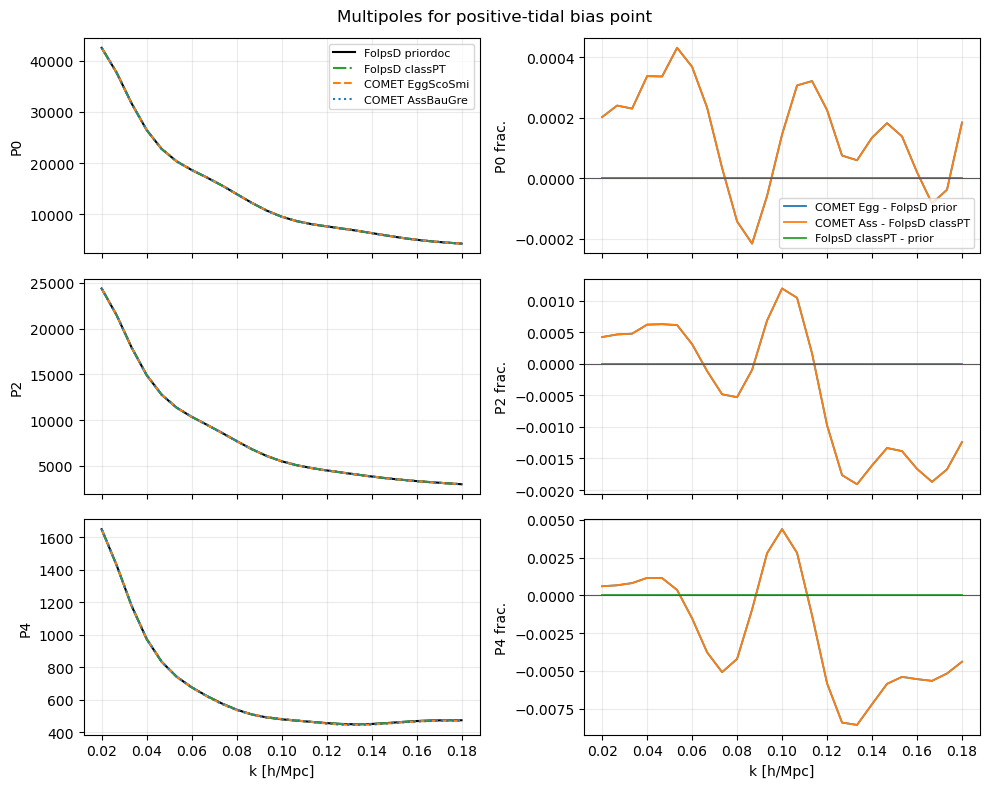

In [9]:
def plot_representative_multipoles(rows, k_eval, representative_label="positive-tidal"):
    slices = multipole_slices(k_eval)
    representative = next(row for row in rows if row["label"] == representative_label)
    spectra = representative["spectra"]

    colors = {
        "folps_priordoc": "black",
        "folps_classpt": "tab:green",
        "comet_egg_from_priordoc": "tab:orange",
        "comet_ass_from_classpt": "tab:blue",
    }
    labels = {
        "folps_priordoc": "FolpsD priordoc",
        "folps_classpt": "FolpsD classPT",
        "comet_egg_from_priordoc": "COMET EggScoSmi",
        "comet_ass_from_classpt": "COMET AssBauGre",
    }
    linestyles = {
        "folps_priordoc": "-",
        "folps_classpt": "-.",
        "comet_egg_from_priordoc": "--",
        "comet_ass_from_classpt": ":",
    }

    fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex="col")
    for row_index, ell in enumerate((0, 2, 4)):
        sl = slices[ell]
        ax_curve = axes[row_index, 0]
        ax_resid = axes[row_index, 1]
        reference = spectra["folps_priordoc"][sl]

        for key in ("folps_priordoc", "folps_classpt", "comet_egg_from_priordoc", "comet_ass_from_classpt"):
            ax_curve.plot(
                k_eval,
                spectra[key][sl],
                color=colors[key],
                ls=linestyles[key],
                lw=1.5,
                label=labels[key] if row_index == 0 else None,
            )

        denom = np.maximum(np.abs(reference), 1.0)
        residual_series = {
            "COMET Egg - FolpsD prior": spectra["comet_egg_from_priordoc"][sl] - reference,
            "COMET Ass - FolpsD classPT": spectra["comet_ass_from_classpt"][sl] - spectra["folps_classpt"][sl],
            "FolpsD classPT - prior": spectra["folps_classpt"][sl] - reference,
        }
        for label, residual in residual_series.items():
            ax_resid.plot(
                k_eval,
                residual / denom,
                lw=1.3,
                label=label if row_index == 0 else None,
            )

        ax_curve.set_ylabel(f"P{ell}")
        ax_resid.set_ylabel(f"P{ell} frac.")
        ax_resid.axhline(0.0, color="0.35", lw=0.8)
        ax_curve.grid(True, alpha=0.25)
        ax_resid.grid(True, alpha=0.25)

    axes[-1, 0].set_xlabel("k [h/Mpc]")
    axes[-1, 1].set_xlabel("k [h/Mpc]")
    axes[0, 0].legend(fontsize=8)
    axes[0, 1].legend(fontsize=8)
    fig.suptitle(f"Multipoles for {representative_label} bias point")
    fig.tight_layout()
    return fig


fig = plot_representative_multipoles(comparison_rows, k_eval)
plt.show()


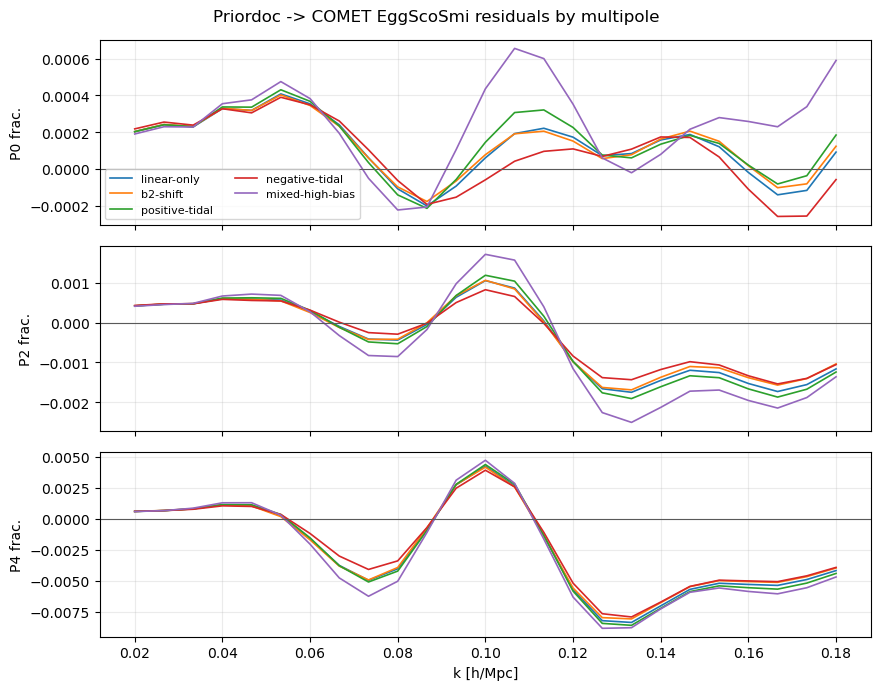

In [10]:
def plot_residuals_by_multipole(rows, k_eval):
    slices = multipole_slices(k_eval)
    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    for ax, ell in zip(axes, (0, 2, 4)):
        sl = slices[ell]
        for row in rows:
            spectra = row["spectra"]
            reference = spectra["folps_priordoc"][sl]
            denom = np.maximum(np.abs(reference), 1.0)
            frac = (spectra["comet_egg_from_priordoc"][sl] - reference) / denom
            ax.plot(k_eval, frac, lw=1.2, label=row["label"])
        ax.axhline(0.0, color="0.35", lw=0.8)
        ax.set_ylabel(f"P{ell} frac.")
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("k [h/Mpc]")
    axes[0].legend(fontsize=8, ncol=2)
    fig.suptitle("Priordoc -> COMET EggScoSmi residuals by multipole")
    fig.tight_layout()
    return fig


fig = plot_residuals_by_multipole(comparison_rows, k_eval)
plt.show()


## Residual summary by multipole


In [11]:
slices = multipole_slices(k_eval)
multipole_rows = []
for ell, sl in slices.items():
    rel_norms = []
    max_fracs = []
    for row in comparison_rows:
        spectra = row["spectra"]
        model = spectra["comet_egg_from_priordoc"][sl]
        reference = spectra["folps_priordoc"][sl]
        rel_norms.append(relative_norm(model, reference))
        max_fracs.append(max_fractional_residual(model, reference))
    multipole_rows.append([f"P{ell}", f"{np.max(rel_norms):.3e}", f"{np.max(max_fracs):.3e}"])

display(
    Markdown(
        markdown_table(
            ["Multipole", "max relative norm residual", "max pointwise fractional residual"],
            multipole_rows,
        )
    )
)


| Multipole | max relative norm residual | max pointwise fractional residual |
| --- | --- | --- |
| P0 | 2.812e-04 | 6.565e-04 |
| P2 | 7.184e-04 | 2.507e-03 |
| P4 | 3.550e-03 | 8.826e-03 |

## Conclusion

The FolpsD `priordoc` tidal parameter `bK2_priordoc` is COMET `g2`.
The FolpsD `priordoc` parameter `btd_priordoc` enters COMET through
`g21 = -4/7*(bK2_priordoc + btd_priordoc)`.  The map has no constant
offset.  The non-zero residuals above are the remaining FolpsD-vs-COMET
numerical/model-emulator differences for this setup.
